In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE  
from imblearn.pipeline import Pipeline     
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  RandomizedSearchCV,GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc


In [2]:
df = pd.read_csv('../../dataset/preprocessed/hotel_bookings.csv')

In [3]:
df_dummy = pd.read_csv('../../dataset/preprocessed/hotel_bookings_dummy.csv')

In [6]:
df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,reservation_date,diff_reserved_room_type
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2014-07-24,False
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2013-06-24,False
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-24,True
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-18,False
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-06-17,False


In [4]:

# string_cols = df.select_dtypes(include=['object']).columns
# number_cols = df.select_dtypes(exclude=['object']).columns


# df[string_cols] = df[string_cols].fillna('Unknown')
# df[number_cols] = df[number_cols].fillna(0)


drop_cols = ['reservation_status', 'reservation_status_date', 'arrival_date', 'reservation_date']
X = df_dummy.drop(columns=[col for col in drop_cols if col in df.columns] + ['is_canceled'])
y = df_dummy['is_canceled']

# X = pd.get_dummies(X, drop_first=True, dtype=float)

In [5]:
# 데이터 분리
X_train,X_test,y_train, y_test = train_test_split(X,y,
                                                  train_size=0.7,
                                                  random_state=1004)

In [6]:
print("모델 학습을 시작")

default_xgb = XGBClassifier(
    n_jobs=-1, 
    random_state=1004, 
    eval_metric='logloss'
)

# 모델 학습
default_xgb.fit(X_train, y_train)

모델 학습을 시작


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
y_pred = default_xgb.predict(X_test)


In [9]:
test_f1 = f1_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)

print(f"  Recall   : {test_recall:.3f}")
print(f"  Precision  : {test_precision:.3f}")
print(f"  F1-Score     : {test_f1:.3f}")



print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['정상 투숙(0)', '예약 취소(1)']))

  Recall   : 0.782
  Precision  : 0.851
  F1-Score     : 0.815
Classification Report
              precision    recall  f1-score   support

    정상 투숙(0)       0.88      0.92      0.90     22390
    예약 취소(1)       0.85      0.78      0.82     13281

    accuracy                           0.87     35671
   macro avg       0.86      0.85      0.86     35671
weighted avg       0.87      0.87      0.87     35671



위까지가 일반 모델

랜덤 서치를 진행합니다. 스코어링은 조화 평균인 f1 score로 지정하고 진행 중입니다

In [57]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


search_pipeline = Pipeline([
    ('smote', SMOTE(random_state=1004)),
    ('classifier', XGBClassifier(
        tree_method='hist',
        device='cuda',          
        random_state=1004,
        eval_metric='logloss'
    ))
])


param_dist = {
    'classifier__n_estimators':[100,200,300,400,500],
    'classifier__max_depth':[3,5,7],
    'classifier__learning_rate': [0.05,0.1],
    'classifier__min_child_weight':[15,20,25,50],
    'classifier__subsample': [ 0.7,0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9]
}


random_search = RandomizedSearchCV(
    estimator=search_pipeline,          
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=8,                               
    random_state=1004,
    n_jobs=1                            
)


random_search.fit(X_train, y_train)

print("=" * 60)
print(f"F1-Score: {random_search.best_score_:.4f}")
print("베스트 파라미터 조합:")
print(random_search.best_params_)
print("=" * 60)

F1-Score: 0.8146
베스트 파라미터 조합:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 15, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.9}


테스트셋 스코어를 확인합니다

In [58]:
from sklearn.metrics import f1_score

# 1. 랜덤 서치 결과에서 가장 성능이 좋았던 최적의 모델을 가져옵니다.
best_model = random_search.best_estimator_

# 2. 최적의 모델에 테스트 데이터(X_test)를 넣어서 취소 여부(0 또는 1)를 예측합니다.
y_pred = best_model.predict(X_test)

# 3. 실제 정답(y_test)과 모델의 예측값(y_pred)을 비교하여 F1 스코어를 계산합니다.
test_f1_score = f1_score(y_test, y_pred)

# 4. 결과를 출력합니다.
print("=" * 50)
print(f"테스트셋(X_test) 최종 F1 스코어: {test_f1_score:.4f}")
print("=" * 50)

테스트셋(X_test) 최종 F1 스코어: 0.8106


최종적으로 사용할 모델의 점수를 확인하거나 저장합니다

1. SMOTE+Tomek 하이브리드 파이프라인 생성 중...
2. 데이터 노이즈 제거 및 최종 실전 점수 검증 중...
[SMOTE+Tomek 적용 최종 성능 평가 결과] X_test 성적표
 Accuracy  (정확도)  : 0.8586
 Precision (정밀도)  : 0.8099
 Recall    (재현율)  : 0.8105
 F1-Score  (조화평균): 0.8102
2-1. 실전 학습 곡선 그래프 생성 중...


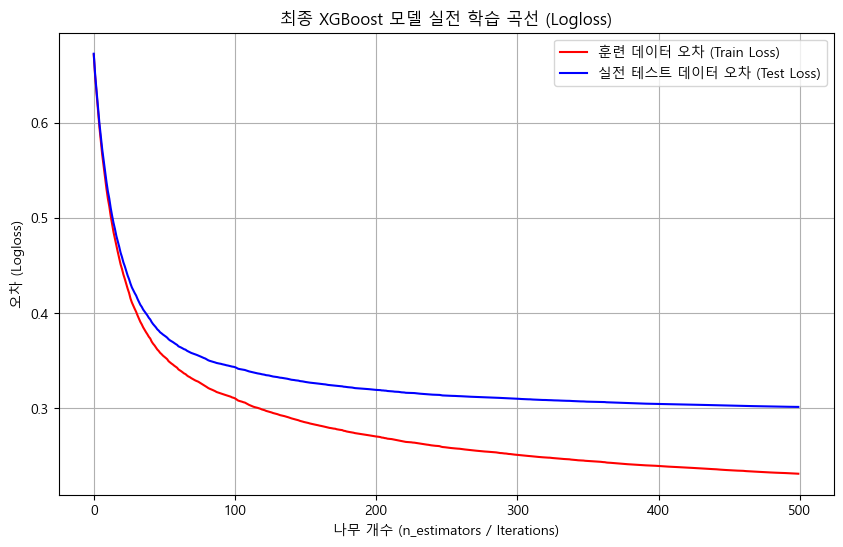

학습 곡선 출력 완료
3. 전체 데이터(X, y) 대상 최종 학습 중...
하이브리드 샘플링 파이프라인이 성공적으로 마무리되었습니다.


In [61]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

# 한글 깨짐 방지 세팅 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("1. SMOTE+Tomek 하이브리드 파이프라인 생성 중...")

# 파이프라인에 SMOTETomek 적용
final_production_model = Pipeline([
    ('smotetomek', SMOTETomek(smote=SMOTE(random_state=1004), random_state=1004)),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.05,
        min_child_weight=15,
        subsample=0.8,
        colsample_bytree=0.9,
        tree_method='hist',
        device='cuda',          
        random_state=1004,
        eval_metric='logloss'
    ))
])

# -------------------------------------------------------------
# 2. 검증 데이터 평가 (X_train -> X_test 최종 실전 점수 확인)
# -------------------------------------------------------------
print("2. 데이터 노이즈 제거 및 최종 실전 점수 검증 중...")
final_production_model.fit(X_train, y_train)
y_pred = final_production_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("[SMOTE+Tomek 적용 최종 성능 평가 결과] X_test 성적표")
print("=" * 60)
print(f" Accuracy  (정확도)  : {accuracy:.4f}")
print(f" Precision (정밀도)  : {precision:.4f}")
print(f" Recall    (재현율)  : {recall:.4f}")
print(f" F1-Score  (조화평균): {f1:.4f}")
print("=" * 60)

# -------------------------------------------------------------
# [추가] 최종 모델 실전 학습 곡선 (Learning Curve) 시각화
# -------------------------------------------------------------
print("2-1. 실전 학습 곡선 그래프 생성 중...")

# 파이프라인에서 수동으로 SMOTETomek 추출하여 학습 데이터 추출
smotetomek_transformer = final_production_model.named_steps['smotetomek']
X_train_res, y_train_res = smotetomek_transformer.fit_resample(X_train, y_train)

# 그래프용 임시 모델 선언 (파이프라인 내부 XGBoost 파라미터와 완벽히 동일)
eval_xgb = final_production_model.named_steps['classifier']

# 학습을 진행하면서 오차(logloss) 변화 기록
eval_xgb.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test, y_test)],
    verbose=False
)

# 기록된 오차 데이터 추출
eval_results = eval_xgb.evals_result()
train_loss = eval_results['validation_0']['logloss']
test_loss = eval_results['validation_1']['logloss']

# 그래프 출력
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='훈련 데이터 오차 (Train Loss)', color='red')
plt.plot(test_loss, label='실전 테스트 데이터 오차 (Test Loss)', color='blue')
plt.title('최종 XGBoost 모델 실전 학습 곡선 (Logloss)')
plt.xlabel('나무 개수 (n_estimators / Iterations)')
plt.ylabel('오차 (Logloss)')
plt.grid(True)
plt.legend(loc='best')
plt.show()

print("학습 곡선 출력 완료")

# -------------------------------------------------------------
# 3. 전체 데이터(X, y) 최종 학습 및 모델 저장
# -------------------------------------------------------------
print("3. 전체 데이터(X, y) 대상 최종 학습 중...")
final_production_model.fit(X, y)

# 학습 완료된 모델을 파일로 저장
# joblib.dump(final_production_model, 'hotel_cancel_model_tomek.pkl')
# print("4. 'hotel_cancel_model_tomek.pkl' 파일 저장 완료")
print("하이브리드 샘플링 파이프라인이 성공적으로 마무리되었습니다.")

아래는 이진 분류(Binary Classification) 머신러닝 모델의 성능을 다양한 임계값(Threshold)에서 시각화한 그래프입니다

그래프가 노란색 밑 너비가 1에 가까울수록 완벽한 분류를 한 것이고 그 반대의 경우는 무작위로 예측하는 수준을 의미합니다

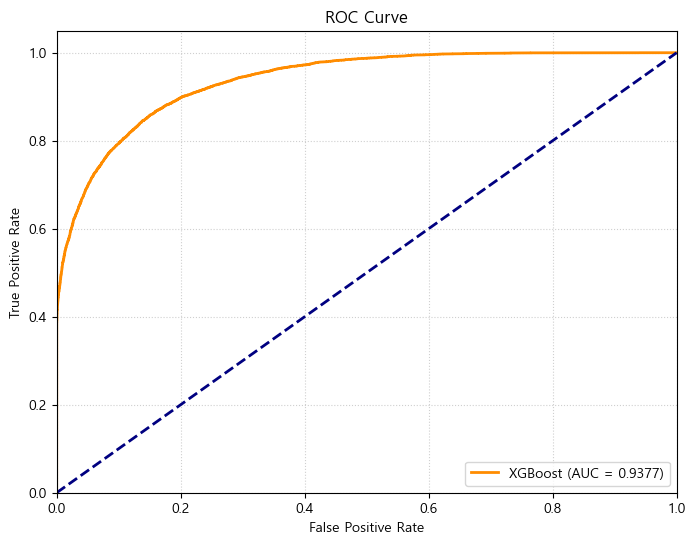

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 최적 모델 추출 및 확률 예측
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# ROC 및 AUC 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

# 1. XGBoost 곡선 그리기
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_score:.4f})')

# 2. 대괄호 증발 오류를 방지하기 위해 list 함수와 튜플로 좌표 생성
x_line = list((0, 1))
y_line = list((0, 1))

# 대각선 기준선 그리기 (이제 , , 에러가 나지 않습니다)
plt.plot(x_line, y_line, color='navy', lw=2, linestyle='--')

# 그래프 스타일 설정
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.05))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
# # 그리드서치
# param_grid = {
#     'classifier__n_estimators':[600],              # 나무의 개수
#     'classifier__max_depth':[7],                    # 나무의 최대 깊이
#     'classifier__learning_rate': [0.1],       # 학습률 (보정 속도)
#     'classifier__min_child_weight':[3],                # 가지치기를 결정하는 최소 관측치 가중치 합
#     'classifier__subsample': [0.7],            # 데이터 샘플링 비율
#     'classifier__colsample_bytree': [0.9],     # 피처 샘플링 비율
# }



# pipeline = Pipeline([
#     ('smote', SMOTE(random_state=1004)),
#     ('classifier', XGBClassifier(tree_method='hist', device='cuda', random_state=1004, eval_metric='logloss'))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1004)

# # GridSearchCV 정의
# grid_search = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,       
#     scoring='f1',                # 평가 기준은 일단 f1 score 이게 조화 평균이기때문
#     cv=cv,
#     n_jobs=-1,
#     verbose=2                    # 실시간 계산 진행 상황 출력
# )


# grid_search.fit(X_train, y_train)



# print("\n" + "="*50)
# print("최종 성적표")
# print("="*50)

# # 최적의 1등 모델 추출 및 전체 데이터 성능 평가
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X)

# # 3대 지표 계산
# final_f1 = f1_score(y, y_pred)
# final_recall = recall_score(y, y_pred)
# final_precision = precision_score(y, y_pred)

# print(f"Grid 모델 성능")
# print(f"Recall  : {final_recall:.4f}")
# print(f"Precision  : {final_precision:.4f}")
# print(f"F1-Score  : {final_f1:.4f}")
# print("-"*50)

# print("Classification Report")
# print(classification_report(y, y_pred, target_names=['정상 투숙(0)', '예약 취소(1)']))
# print("-"*50)

# print("베스트 하이퍼파라미터")
# best_params = grid_search.best_params_
# for param, value in best_params.items():
#     clean_param = param.replace('classifier__', '')
#     print(f"  • {clean_param} : {value}")
# print("="*50)

In [ ]:
# from sklearn.metrics import f1_score

# # 1. 랜덤 서치 결과에서 가장 성능이 좋았던 최적의 모델을 가져옵니다.
# best_model = grid_search.best_estimator_

# # 2. 최적의 모델에 테스트 데이터(X_test)를 넣어서 취소 여부(0 또는 1)를 예측합니다.
# y_pred = best_model.predict(X_test)

# # 3. 실제 정답(y_test)과 모델의 예측값(y_pred)을 비교하여 F1 스코어를 계산합니다.
# test_f1_score = f1_score(y_test, y_pred)

# # 4. 결과를 출력합니다.
# print("=" * 50)
# print(f"테스트셋(X_test) 최종 F1 스코어: {test_f1_score:.4f}")
# print("=" * 50)